In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import (
    OUTPUT_PATH, WHOLE_POP, MODE, POOL_FILTERS,
)

plt.rcParams.update({"font.size": 16})

# Stimulus / belief population-vector alignment

Step 2 of `claude_notes/stim_belief_alignment_updated.md`. On correct trials only, relative to a
feature X, three groups:

```
A: X not chosen, X not preferred      B: X chosen, X not preferred      C: X chosen, X preferred
```

and two mean-difference vectors over z-scored activity, with per-unit coordinates concatenated
across sessions:

```
v_stim = r_B1 - r_A     # selection of X, holding belief fixed
v_pref = r_C  - r_B2    # preference for X, holding selection fixed
```

The plot shows `cos(v_stim, v_pref)` against its session-permute shuffle. **H1** (stimulus and
belief codes are disjoint) predicts ~0; **H2** (preference scales the same encoding) predicts > 0.
Error bands are SE across the 12 features.

This replaces the two-contrast analysis in `20260811_visualize_choice_pref_alignment.ipynb`. There
`v_choice` and `v_pref` come from independently filtered pools with their own z-scoring, so the
selection contrast is confounded with belief; here one pool is split three ways, both vectors share
one metric, and each contrast holds the other variable fixed. Computed by
`scripts/pseudo_decoding/belief_partitions/stim_belief_vector_alignment.py`.

## Why group B is halved

B is split into disjoint halves B1, B2, and that is not a refinement -- it is what makes the number
readable. B enters both vectors with opposite signs, so sharing it would put
`E<eps_stim, eps_pref> = -E||e_B||^2` into the numerator: a structurally negative cross-term, worth
about **-0.44 to -0.65** under the null at these trial counts (measured / predicted, Issue 1 of the
note). H1 would then read as strong anti-alignment and H2 as roughly zero -- exactly backwards.
Disjoint halves make that term exactly zero. The check that it worked is the **shuffle sitting near
0** in the summary table at the bottom, rather than near -0.5.

Nothing is subsampled: all ~294 A, all ~65 B (halved), all ~55 C trials per (session, feature). A
mean-difference vector has no need for equal n, so this analysis is deliberately not trial-matched
to the decoding runs.

**One run covers every population.** Each unit's coordinate is computed independently of every
other unit's, so a region is a subset of the same per-unit vectors rather than a separate fit --
`region` is a column in the results, not a separate run directory. Units outside the 6 regions of
interest still count toward `whole_pop`, so the regions do not sum to the whole population.

## How to read the magnitude -- important

**`cos_raw` is not deattenuated, so its value is not a percentage of alignment.** Finite-trial noise
inflates both norms in the denominator, by a factor that varies across time bins, and halving B
makes that worse for both vectors. So:

- read it **only** as a contrast against its own shuffle,
- do **not** read a `cos_raw` of 0.05 as "5% aligned" -- the true value is several-fold larger,
- do **not** compare one time bin, one feature, **or one region** against another as if differences
  in `cos_raw` were differences in alignment.

That last point bites hardest for regions: a region contributes 15-141 units per feature against
382-681 for the whole population, and fewer units means more attenuation. A regional dissociation
claim needs unit-count-matched subsampling first (`choice_pref_axis_geometry.md` shared caveat 3),
which the saved per-unit `*_vectors.pickle` files support without re-running anything.

Unlike the choice_pref analysis, the fix is also available here without a re-run: the compute script
saves per-unit `r_A/r_B1/r_B2/r_C`, their within-group variances `s2_*`, and `n_*` per group, so the
unbiased estimator and the attenuation factors of
`claude_notes/cosine_similarity_debiasing.md` section 5 are a groupby over those files, on the
shuffles as well as the true run. `att_*` answers the question `cos_raw` cannot -- whether a
near-zero cosine means "disjoint codes" (H1) or "no measurable signal in either vector".

Significance bars are the one-sided permutation test of each population against **its own** shuffle
at each timepoint, thicker for smaller p (p < 0.05 / 0.01 / 0.001,
`visualization_utils.SIG_LEVELS`), written by
`scripts/pseudo_decoding/p_val_computations/compute_p_vals_for_stim_belief_align.py`. Significance
*is* comparable across regions; magnitude is not.

In [2]:
# one run per event, unlike the choice_pref analysis: the A/B/C groups fix the pool to correct
# trials, so there is no filter variant to pick between here
RUN_MODE = MODE

SERIES_NAMES = {
    RUN_MODE: "alignment",
    f"{RUN_MODE}_shuffle": "alignment shuffle",
}
SERIES_ORDER = ["alignment", "alignment shuffle"]
SERIES_TO_COLOR = {"alignment": "tab:purple", "alignment shuffle": "#c5b0d5"}
SIG_BAR_SERIES = ["alignment"]

TRIAL_EVENTS = ["StimOnset", "FeedbackOnsetLong"]
# whole population first, then the 6 regions of interest
POPULATIONS = [WHOLE_POP] + list(REGIONS_OF_INTEREST)


def get_args(trial_event):
    """
    Every population lives in one run dir, so region is not part of the naming. The pool filter IS
    part of it -- POOL_FILTERS has to be set or the run dir won't resolve. That differs from the
    choice_pref analysis, where two contrasts with different filters shared a dir and the choice
    contrast's filters rode in the mode name instead.
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = RUN_MODE
    args.trial_event = trial_event
    args.base_output_path = OUTPUT_PATH
    args.region_level = None
    args.regions = None
    args.sig_unit_level = None
    args.beh_filters = POOL_FILTERS
    return args


def read_alignment(trial_event, region=None):
    """
    True run plus shuffles, one row per (region, feat, TimeIdx) per run
    """
    res = belief_partitions_io.read_alignment(get_args(trial_event))
    if region is not None:
        res = res[res.region == region]
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


def read_pvals(trial_event, region):
    """
    Per-timepoint p value of one population against its own shuffle, written by
    p_val_computations/compute_p_vals_for_stim_belief_align.py
    """
    dir = belief_partitions_io.get_dir_name(get_args(trial_event), make_dir=False)
    p_vals = pd.read_pickle(os.path.join(dir, f"{RUN_MODE}_pvals.pickle"))
    return p_vals[p_vals.region == region]

In [3]:
def plot_alignment(region, title=None):
    """
    Both trial events side by side, in the style of visualization_utils.plot_combined_accs
    """
    stim_res = read_alignment("StimOnset", region)
    fb_res = read_alignment("FeedbackOnsetLong", region)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        sns.lineplot(
            res, x="Time", y="cos_raw", hue="series", hue_order=SERIES_ORDER,
            palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
        )
        # 0 is what H1 predicts, but it is NOT the null -- the shuffle is
        ax.axhline(y=0, linestyle="dotted", color="black")
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    # significance vs. this population's own shuffle, below the traces. Read the shared limits
    # before any bar has a chance to rescale the axes.
    bottom, top = ax1.get_ylim()
    spacing = 0.08 * (top - bottom)
    for ax, trial_event in ((ax1, "StimOnset"), (ax2, "FeedbackOnsetLong")):
        p_vals = read_pvals(trial_event, region)
        for i, series in enumerate(SIG_BAR_SERIES):
            visualization_utils.plot_sig_bars(
                p_vals, bottom - (i + 1) * spacing, ax, color=SERIES_TO_COLOR[series]
            )
    # shared y, so these set both: make room for the bars without rescaling the traces, and keep
    # the ticks on the traces, since a cos_raw tick inside the bar strip reads as data
    ax1.set_ylim(bottom - (len(SIG_BAR_SERIES) + 0.5) * spacing, top)
    ax1.set_yticks([tick for tick in ax1.get_yticks() if bottom <= tick <= top])

    ax1.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
    ax1.set_xlabel("Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylabel("cos(v_stim, v_pref)")

    ax2.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax2.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)

    visualization_utils.format_plot([ax1, ax2])
    ax1.get_legend().remove()
    ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population

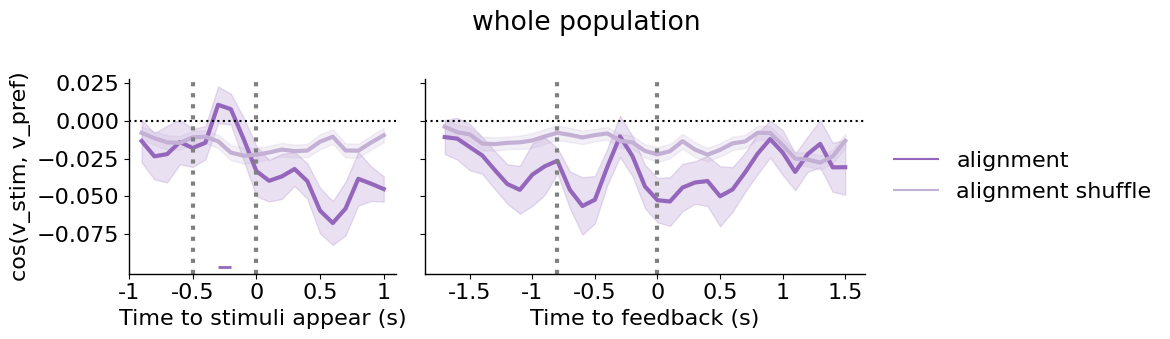

In [4]:
fig, _, whole_pop_res = plot_alignment(WHOLE_POP, title="whole population")

## Regions of interest

Each region against its own shuffle. Recall the y axes are not comparable between regions -- see
the note at the top.

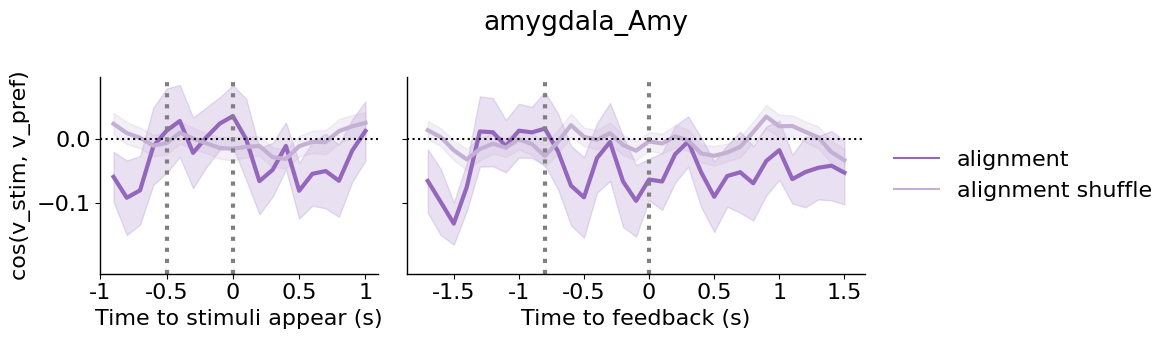

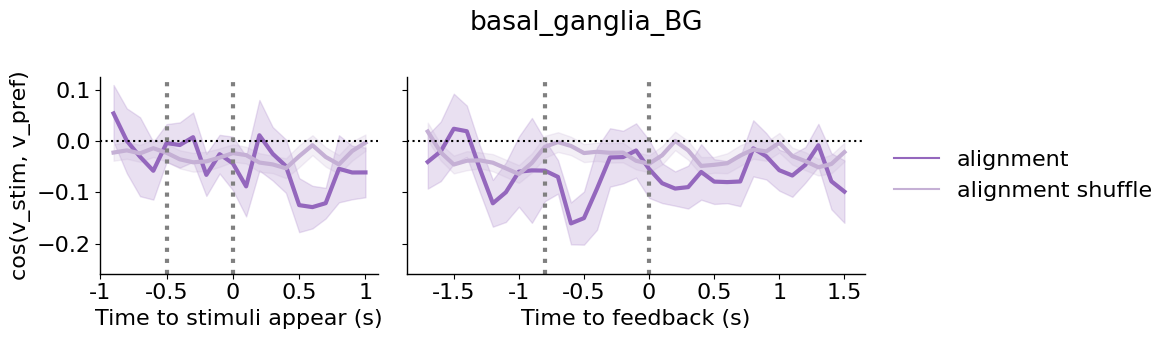

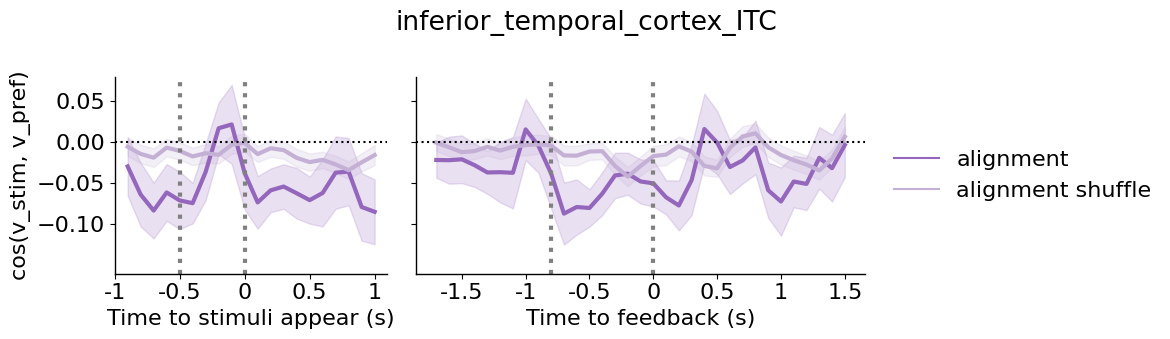

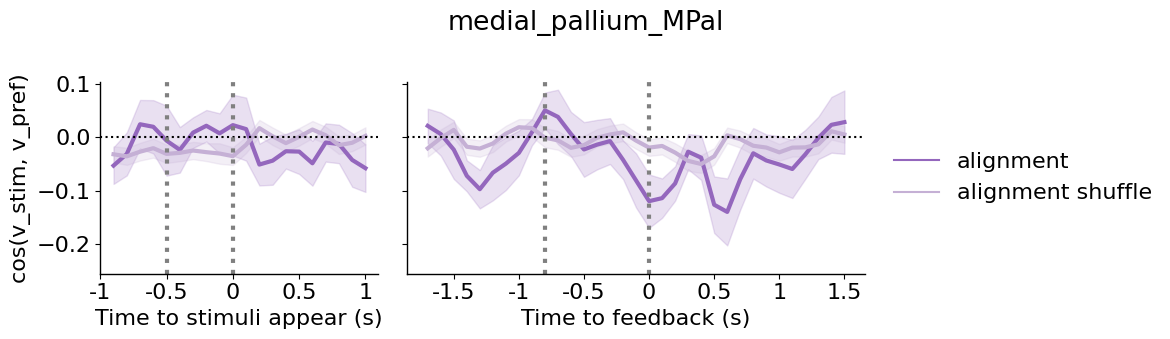

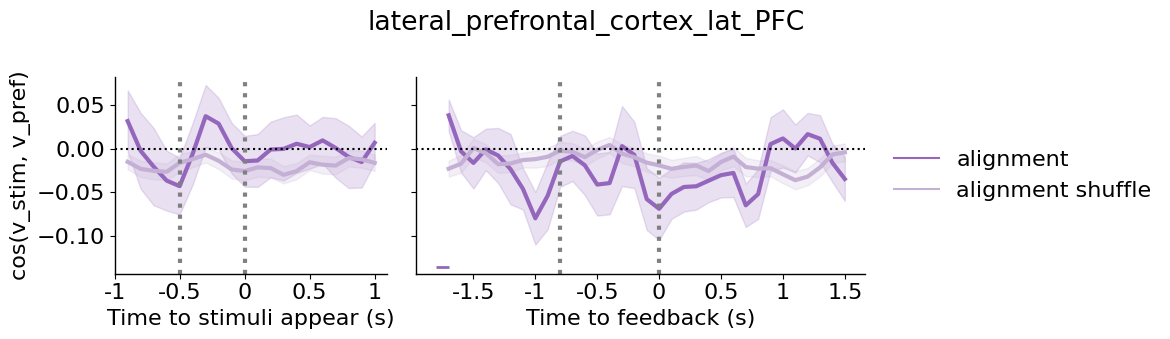

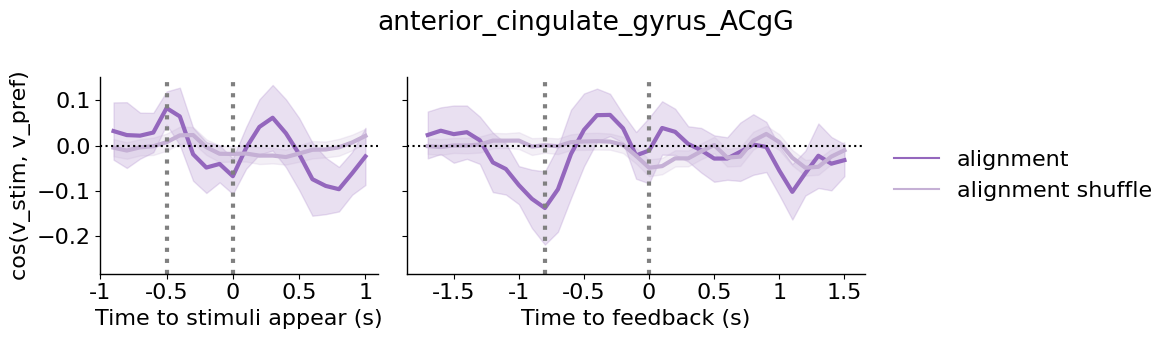

In [5]:
all_res = [whole_pop_res]
for region in POPULATIONS[1:]:
    _, _, res = plot_alignment(region, title=region)
    all_res.append(res)
all_res = pd.concat(all_res)

## Significant timepoints per region

Timepoints where the alignment sits above its own shuffle, one row per population.

In [6]:
sig = []
for trial_event in TRIAL_EVENTS:
    for region in POPULATIONS:
        p = read_pvals(trial_event, region)
        hits = p[p.p < 0.05].Time.to_numpy()
        sig.append({
            "trial_event": trial_event, "region": region,
            "n_sig_bins": len(hits), "n_bins": len(p), "min_p": p.p.min(),
            "sig_window": f"{hits.min():+.1f} to {hits.max():+.1f}" if len(hits) else "-",
            "sig_times": np.round(hits, 1),
        })
sig = pd.DataFrame(sig).set_index(["trial_event", "region"])
sig[["n_sig_bins", "n_bins", "min_p", "sig_window"]]

n_sig_bins  n_bins  \
trial_event       region                                                  
StimOnset         whole_pop                                   1      20   
                  amygdala_Amy                                0      20   
                  basal_ganglia_BG                            0      20   
                  inferior_temporal_cortex_ITC                0      20   
                  medial_pallium_MPal                         0      20   
                  lateral_prefrontal_cortex_lat_PFC           0      20   
                  anterior_cingulate_gyrus_ACgG               0      20   
FeedbackOnsetLong whole_pop                                   0      33   
                  amygdala_Amy                                0      33   
                  basal_ganglia_BG                            0      33   
                  inferior_temporal_cortex_ITC                0      33   
                  medial_pallium_MPal                         0      33   
                  lateral_prefrontal_cortex_lat_PFC           1      33   
                  anterior_cingulate_gyrus_ACgG               0      33   

                                                     min_p    sig_window  
trial_event       region                                                  
StimOnset         whole_pop                          0.041  -0.2 to -0.2  
                  amygdala_Amy                       0.202             -  
                  basal_ganglia_BG                   0.073             -  
                  inferior_temporal_cortex_ITC       0.185             -  
                  medial_pallium_MPal                0.150             -  
                  lateral_prefrontal_cortex_lat_PFC  0.059             -  
                  anterior_cingulate_gyrus_ACgG      0.071             -  
FeedbackOnsetLong whole_pop                          0.188             -  
                  amygdala_Amy                       0.234             -  
                  basal_ganglia_BG                   0.116             -  
                  inferior_temporal_cortex_ITC       0.109             -  
                  medial_pallium_MPal                0.194             -  
                  lateral_prefrontal_cortex_lat_PFC  0.027  -1.7 to -1.7  
                  anterior_cingulate_gyrus_ACgG      0.080             -

In [7]:
# the individual significant timepoints, if the windows above are not contiguous
for (trial_event, region), row in sig.iterrows():
    print(f"{trial_event:18s} {region:34s} {row.sig_times}")

StimOnset          whole_pop                          [-0.2]
StimOnset          amygdala_Amy                       []
StimOnset          basal_ganglia_BG                   []
StimOnset          inferior_temporal_cortex_ITC       []
StimOnset          medial_pallium_MPal                []
StimOnset          lateral_prefrontal_cortex_lat_PFC  []
StimOnset          anterior_cingulate_gyrus_ACgG      []
FeedbackOnsetLong  whole_pop                          []
FeedbackOnsetLong  amygdala_Amy                       []
FeedbackOnsetLong  basal_ganglia_BG                   []
FeedbackOnsetLong  inferior_temporal_cortex_ITC       []
FeedbackOnsetLong  medial_pallium_MPal                []
FeedbackOnsetLong  lateral_prefrontal_cortex_lat_PFC  [-1.7]
FeedbackOnsetLong  anterior_cingulate_gyrus_ACgG      []


## Summary

Mean `cos_raw` over all time bins, features and runs, and the gap over the shuffle. The **gap** is
the interpretable quantity within a population; absolute levels are attenuated by an unknown factor
that differs between populations, so the `gap` column is not a cross-region ranking either.

Two things to read off the `alignment shuffle` column, before anything else:

1. It should sit **near 0**, not near -0.5. That is the check that the B half-split killed the
   shared-group cross-term -- see the note at the top.
2. It is not exactly 0. That residual is the neural-drift x belief-autocorrelation interaction
   documented in `claude_notes/trial_subselection_autocorrelation_matching.md`, which the split does
   not touch, and it is why the shuffle rather than 0 is the reference the `gap` is taken against.

In [8]:
summary = all_res.groupby(["trial_event", "region", "series"]).cos_raw.mean().unstack("series")
summary["gap"] = summary["alignment"] - summary["alignment shuffle"]
units = all_res[all_res["mode"] == RUN_MODE].groupby(["trial_event", "region"]).n_units.agg(["min", "max"])
summary = summary.join(units.rename(columns={"min": "units_min", "max": "units_max"}))
summary = summary.reindex(TRIAL_EVENTS, level="trial_event").reindex(POPULATIONS, level="region")
summary.round(4)

alignment  \
trial_event       region                                         
StimOnset         whole_pop                            -0.0295   
                  amygdala_Amy                         -0.0266   
                  basal_ganglia_BG                     -0.0437   
                  inferior_temporal_cortex_ITC         -0.0516   
                  medial_pallium_MPal                  -0.0154   
                  lateral_prefrontal_cortex_lat_PFC    -0.0020   
                  anterior_cingulate_gyrus_ACgG        -0.0080   
FeedbackOnsetLong whole_pop                            -0.0328   
                  amygdala_Amy                         -0.0444   
                  basal_ganglia_BG                     -0.0617   
                  inferior_temporal_cortex_ITC         -0.0372   
                  medial_pallium_MPal                  -0.0382   
                  lateral_prefrontal_cortex_lat_PFC    -0.0244   
                  anterior_cingulate_gyrus_ACgG        -0.0173   

                                                     alignment shuffle  \
trial_event       region                                                 
StimOnset         whole_pop                                    -0.0158   
                  amygdala_Amy                                 -0.0022   
                  basal_ganglia_BG                             -0.0288   
                  inferior_temporal_cortex_ITC                 -0.0150   
                  medial_pallium_MPal                          -0.0149   
                  lateral_prefrontal_cortex_lat_PFC            -0.0191   
                  anterior_cingulate_gyrus_ACgG                -0.0052   
FeedbackOnsetLong whole_pop                                    -0.0147   
                  amygdala_Amy                                 -0.0040   
                  basal_ganglia_BG                             -0.0290   
                  inferior_temporal_cortex_ITC                 -0.0129   
                  medial_pallium_MPal                          -0.0101   
                  lateral_prefrontal_cortex_lat_PFC            -0.0148   
                  anterior_cingulate_gyrus_ACgG                -0.0086   

                                                        gap  units_min  \
trial_event       region                                                 
StimOnset         whole_pop                         -0.0137        382   
                  amygdala_Amy                      -0.0244         21   
                  basal_ganglia_BG                  -0.0149         15   
                  inferior_temporal_cortex_ITC      -0.0366         42   
                  medial_pallium_MPal               -0.0005         29   
                  lateral_prefrontal_cortex_lat_PFC  0.0171         68   
                  anterior_cingulate_gyrus_ACgG     -0.0028         19   
FeedbackOnsetLong whole_pop                         -0.0181        382   
                  amygdala_Amy                      -0.0404         21   
                  basal_ganglia_BG                  -0.0327         15   
                  inferior_temporal_cortex_ITC      -0.0243         42   
                  medial_pallium_MPal               -0.0281         29   
                  lateral_prefrontal_cortex_lat_PFC -0.0096         68   
                  anterior_cingulate_gyrus_ACgG     -0.0087         19   

                                                     units_max  
trial_event       region                                        
StimOnset         whole_pop                                681  
                  amygdala_Amy                              54  
                  basal_ganglia_BG                          47  
                  inferior_temporal_cortex_ITC             114  
                  medial_pallium_MPal                       72  
                  lateral_prefrontal_cortex_lat_PFC        141  
                  anterior_cingulate_gyrus_ACgG             50  
FeedbackOnsetLong whole_pop              